<a href="https://colab.research.google.com/github/prince-musonda/Admin-DashBoard/blob/main/contextual_bandit_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contextual Bandit Problem

You own 10 e-commerce websites that sell different kind of items. The goal to build a simulated recommendation reinforcement learning agent system that looks at the current website the user is on (the state) during checkout and shows a targeted ad to one of your other websites that the user is likely to click on. you have 10 possible actions and 10 possible states.

In [15]:
import numpy as np
# build the simulated environment

class contextBandit():
  def __init__(self,arms=10):
    self.arms = arms
    self.init_distrubtion(arms) # likelyhoods of user click on ad z when in state x  --> colllection of states[rows] and probabilitys of clicking on action x [columns]
    self.update_state() # generate random state

  def init_distrubtion(self,arms):
    self.bandit_matrix = np.random.rand(arms,arms) # number of staes = number of arms. Each row reprents a state and each column an arm

  def reward(self, prob):
    reward = 0
    for i in range(self.arms):
      if np.random.random() < prob:
        reward +=  1
    return reward

  def get_state(self):
    return self.state

  def update_state(self):
    self.state = np.random.randint(0,self.arms) # generate a random state from n(arms) possible state

  def get_reward(self,arm):
    current_state = self.get_state()
    prob_distribution = self.bandit_matrix[current_state][arm]
    return self.reward(prob_distribution)

  def choose_arm(self,arm):
    reward = self.get_reward(arm)
    self.update_state()
    return reward

In [16]:
# initiate environment
arms = 10
env = contextBandit(arms)

In [92]:
import torch

In [114]:
model = torch.nn.Sequential(
    torch.nn.Linear(arms, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 10),
    torch.nn.ReLU()
)

In [115]:
loss_fn = torch.nn.MSELoss()

In [116]:
def one_hot(N, pos, val=1):
  one_hot_vec = np.zeros(N)
  one_hot_vec[pos] = val
  return one_hot_vec

def softmax(vec, tau=1.2):
  computation = np.exp(vec/tau)/np.sum(np.exp(vec/tau))
  return computation


In [117]:
def train(env, epochs=5000, learning_rate=1e-2):
  current_state = torch.Tensor(one_hot(arms,env.get_state()))
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
  rewards = []
  for i in range(epochs):
    y_pred = model(current_state)
    av_softmax = softmax(y_pred.data.numpy(), tau = 2.0) # propability distrubition for selection an action
    av_softmax /= np.sum(av_softmax) # normalizing distrubtion to make sure it sums to 1 because floating point precision can sometimes cause errors in the next line if doesn't sum to one (e.g 1.0000001)
    choice = np.random.choice(arms, p=av_softmax)
    cur_reward = env.choose_arm(choice)
    one_hot_reward = y_pred.data.numpy().copy() # convert to numpy
    one_hot_reward[choice] = cur_reward
    reward = torch.Tensor(one_hot_reward)
    rewards.append(cur_reward)
    loss = loss_fn(y_pred,reward)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    current_state = torch.Tensor(one_hot(arms,env.get_state()))
  return np.array(rewards)





In [118]:
results = train(env)

In [119]:
np.mean(results)

np.float64(7.9042)

In [120]:
from matplotlib import pyplot as plt
def plot_results(data):
  window = 50
  new_data = []
  for i in range(0,int(len(data)),window):
    chunk = data[i:window+i]
    avg = np.sum(chunk)/window
    new_data.append(avg)
  plt.scatter(np.arange(len(new_data)),new_data, c=new_data,s=10)
  plt.show

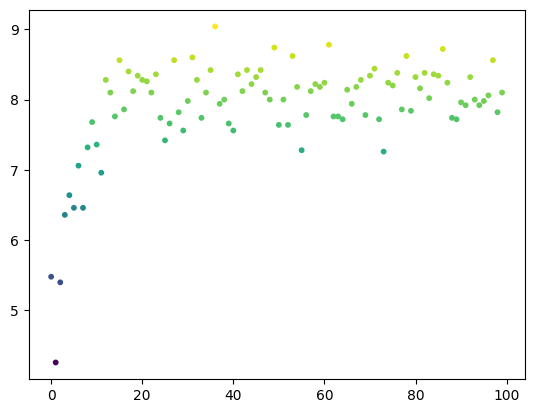

In [121]:
plot_results(results)